In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy import stats

#this is entirely AI generated code to create a Menger sponge of a given order, meant only to validate my own FD calculations.
def menger_sponge(order):

    def recurse(n):
        if n == 0:
            return np.ones((1, 1, 1), dtype=int)
        
        # Get the smaller sponge
        small = recurse(n - 1)
        size = small.shape[0]
        
        # Create a 3x3x3 grid of smaller sponges
        new_size = size * 3
        sponge = np.zeros((new_size, new_size, new_size), dtype=int)
        
        for x in range(3):
            for y in range(3):
                for z in range(3):
                    # Skip the central parts along any axis
                    if (x == 1 and y == 1) or (x == 1 and z == 1) or (y == 1 and z == 1):
                        continue
                    sponge[x*size:(x+1)*size, y*size:(y+1)*size, z*size:(z+1)*size] = small
        return sponge
    
    return recurse(order)

# Example usage
order = 4  # Try 0, 1, 2, 3
ROI = menger_sponge(order)
print(f"Menger Sponge of order {order} shape: {ROI.shape}")
print(ROI)

Menger Sponge of order 4 shape: (81, 81, 81)
[[[1 1 1 ... 1 1 1]
  [1 0 1 ... 1 0 1]
  [1 1 1 ... 1 1 1]
  ...
  [1 1 1 ... 1 1 1]
  [1 0 1 ... 1 0 1]
  [1 1 1 ... 1 1 1]]

 [[1 0 1 ... 1 0 1]
  [0 0 0 ... 0 0 0]
  [1 0 1 ... 1 0 1]
  ...
  [1 0 1 ... 1 0 1]
  [0 0 0 ... 0 0 0]
  [1 0 1 ... 1 0 1]]

 [[1 1 1 ... 1 1 1]
  [1 0 1 ... 1 0 1]
  [1 1 1 ... 1 1 1]
  ...
  [1 1 1 ... 1 1 1]
  [1 0 1 ... 1 0 1]
  [1 1 1 ... 1 1 1]]

 ...

 [[1 1 1 ... 1 1 1]
  [1 0 1 ... 1 0 1]
  [1 1 1 ... 1 1 1]
  ...
  [1 1 1 ... 1 1 1]
  [1 0 1 ... 1 0 1]
  [1 1 1 ... 1 1 1]]

 [[1 0 1 ... 1 0 1]
  [0 0 0 ... 0 0 0]
  [1 0 1 ... 1 0 1]
  ...
  [1 0 1 ... 1 0 1]
  [0 0 0 ... 0 0 0]
  [1 0 1 ... 1 0 1]]

 [[1 1 1 ... 1 1 1]
  [1 0 1 ... 1 0 1]
  [1 1 1 ... 1 1 1]
  ...
  [1 1 1 ... 1 1 1]
  [1 0 1 ... 1 0 1]
  [1 1 1 ... 1 1 1]]]


In [2]:
def voxel_box_counting(box_size):
    x, y, z = ROI.shape
    sx= sy= sz = box_size
    reshaped_ROI = ROI.reshape(
        x // sx, sx,
        y // sy, sy,
        z // sz, sz

    ).sum(axis=(1, 3, 5))   #reshape into a new array of box size *box size * box size dimensions
    num_boxes= int((np.sum(reshaped_ROI > 0))) #count the number of new voxels that fill the shape
    binary = np.any(reshaped_ROI)

    return num_boxes

In [3]:
y = np.zeros(40)
x=np.zeros(40)
idx = 0
for i in range(ROI.shape[0]):
    box_size= i+1
    if ROI.shape[0]%box_size==0 and box_size<=81:
        box_size=int(box_size)
        num_box= voxel_box_counting(box_size)
        y[idx]= num_box
        x[idx]= box_size
        idx += 1
x = x.astype(int)
y = y.astype(int)   
y=y[0:idx]
x=x[0:idx]

In [4]:


log_x= np.log(x)
log_y=np.log(y)

print(x,y)
print(log_x,log_y)

[ 1  3  9 27 81] [160000   8000    400     20      1]
[0.         1.09861229 2.19722458 3.29583687 4.39444915] [11.98292909  8.98719682  5.99146455  2.99573227  0.        ]


fractal dimension is 2.7268330278608426 and r2 is  1.0


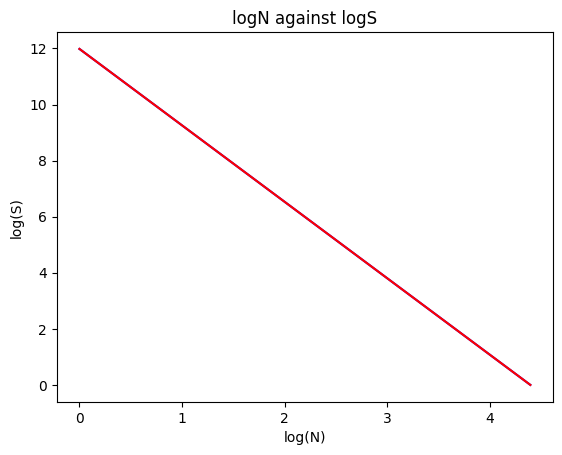

In [5]:
rf_log_x = log_x[0:8]
rf_log_y = log_y[0:8]
plt.plot(rf_log_x,rf_log_y,color='blue')
plt.title('logN against logS')
plt.xlabel("log(N)")
plt.ylabel('log(S)')
m, c = np.polyfit(rf_log_x, rf_log_y, 1)
best_fit_line = m*rf_log_x + c
plt.plot(rf_log_x, m*rf_log_x + c, color='red') 
fd = -m
correlation_coefficient = np.corrcoef(rf_log_x, rf_log_y)[0, 1]
r2 = correlation_coefficient**2

print("fractal dimension is", fd,"and r2 is ", r2)

In [6]:

#here is my method for systematically finding the best estimate, used on the menger sponge

widest_range = 0 
best_fd = 0
best_r2 = 0
min_j = 0
max_k = 0
for j in range(1, idx):
    for k in range(1, idx):
        if k > j:
            rf_log_x = log_x[j:k+1]
            rf_log_y = log_y[j:k+1]
            slope, intercept, r_value, p_value, std_err = stats.linregress(rf_log_x, rf_log_y)
            r2 = r_value**2
            fd = -slope
            if 0.995 < r2 < 1: 
                if k-j> widest_range and r2 >= best_r2:
                    widest_range = k - j
                    min_j = j
                    max_k = k
                    best_fd = fd
                    best_r2 = r2    
print("Fractal Dimension is: ", best_fd)
print("its R-squared value is: ", best_r2)
print("ideal range is from box sizes: ", x[min_j] , " to ", x[max_k])

Fractal Dimension is:  2.7268330278608417
its R-squared value is:  0.9999999999999996
ideal range is from box sizes:  3  to  27
